## 1. Setup and GPU Verification

In [1]:
# Install Ultralytics YOLOv8 package
!pip install ultralytics

import torch
from ultralytics import YOLO

# Verify that GPU acceleration is enabled
print(f"Using PyTorch version: {torch.__version__}")
if torch.cuda.is_available():
    print(f"✅ GPU is available: {torch.cuda.get_device_name(0)}")
else:
    print("⚠️ GPU is NOT available. Go to Runtime -> Change runtime type -> Select T4 GPU.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Using PyTorch version: 2.11.0+cu128
✅ GPU is available: Tesla T4


## 2. Dataset Download and Project Setup

In [2]:
!mkdir -p /content/car_damage_project
%cd /content/car_damage_project

# 2. Download the ZIP file using your specific Google Drive File ID
!gdown --id 16RA6H9RMNg19ORzo7s1prMHxnuz2qyAA -O custom_dataset.zip

# 3. Unzip the file into a new folder named 'custom_dataset'
# (-q keeps the output quiet so it doesn't flood your screen)
!unzip -q custom_dataset.zip -d custom_dataset

# 4. Save the folder path to a variable for your training script
dataset_location = '/content/car_damage_project/custom_dataset'
print(f"✅ Dataset successfully downloaded and extracted to: {dataset_location}")

/content/car_damage_project
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=16RA6H9RMNg19ORzo7s1prMHxnuz2qyAA
From (redirected): https://drive.google.com/uc?id=16RA6H9RMNg19ORzo7s1prMHxnuz2qyAA&confirm=t&uuid=d45c6237-c1be-4fb4-9391-f46a7353c4ed
To: /content/car_damage_project/custom_dataset.zip
100% 153M/153M [00:01<00:00, 141MB/s]
replace custom_dataset/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
✅ Dataset successfully downloaded and extracted to: /content/car_damage_project/custom_dataset


## 3.1 Data Distribution Analysis

Successfully located data.yaml at: /content/car_damage_project/custom_dataset/data.yaml
Counting training set labels...
Counting validation set labels...


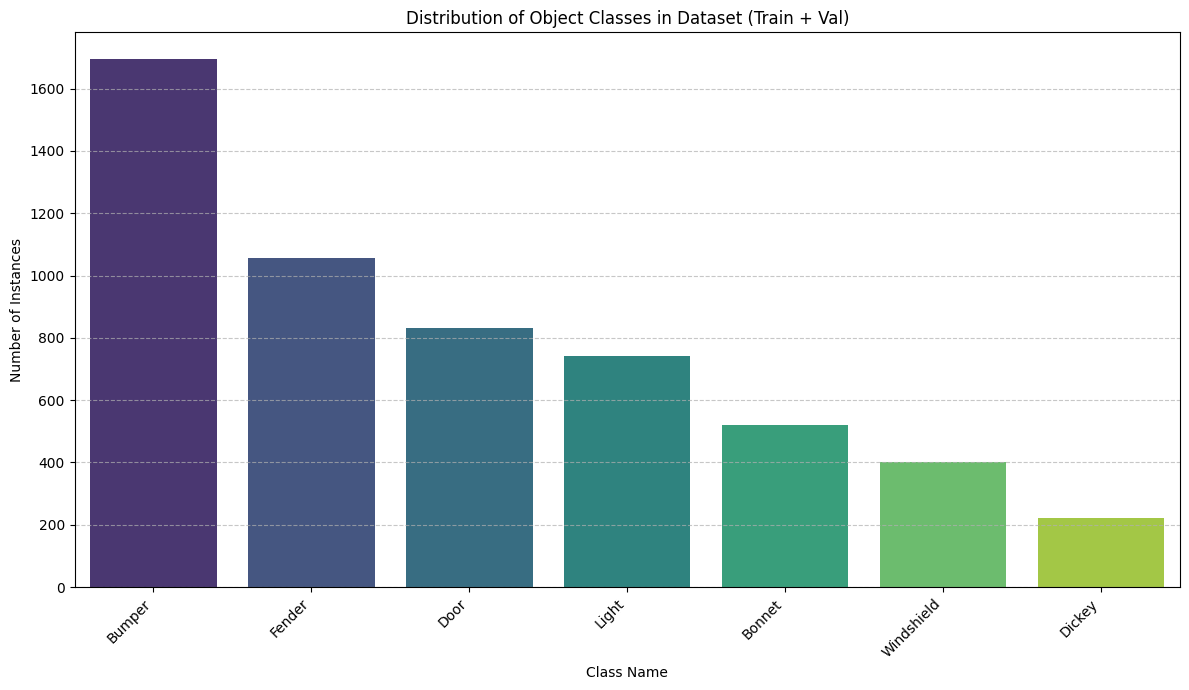

In [3]:
import yaml
import os
from glob import glob
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Path to the data.yaml file, which is directly available after dataset.download()
data_yaml_path = f"{dataset_location}/data.yaml"

# Ensure the file exists (though it should after successful download/extraction)
if not os.path.exists(data_yaml_path):
    raise FileNotFoundError(f"data.yaml not found at: {data_yaml_path}. Please ensure the dataset is downloaded and extracted correctly.")

print(f"Successfully located data.yaml at: {data_yaml_path}")

with open(data_yaml_path, 'r') as f:
    data_config = yaml.safe_load(f)

class_names = data_config['names']
num_classes = data_config['nc']

# Paths to label directories
# These paths are relative to the *extracted dataset root* (dataset.location)
base_dataset_dir = dataset_location
train_labels_dir = os.path.join(base_dataset_dir, 'train', 'labels')
val_labels_dir = os.path.join(base_dataset_dir, 'valid', 'labels')

class_counts = {name: 0 for name in class_names}

def count_labels(label_dir, counts_dict):
    if not os.path.exists(label_dir):
        print(f"Warning: Label directory not found: {label_dir}")
        return
    for label_file in glob(os.path.join(label_dir, '*.txt')):
        with open(label_file, 'r') as f:
            for line in f:
                parts = line.strip().split(' ')
                if parts:
                    try:
                        class_id = int(parts[0])
                        if class_id < len(class_names):
                            counts_dict[class_names[class_id]] += 1
                    except ValueError:
                        print(f"Warning: Could not parse class ID in file {label_file}: {line.strip()}")

print("Counting training set labels...")
count_labels(train_labels_dir, class_counts)
print("Counting validation set labels...")
count_labels(val_labels_dir, class_counts)

# Convert to DataFrame for easier plotting
df_class_counts = pd.DataFrame(class_counts.items(), columns=['Class', 'Count'])

plt.figure(figsize=(12, 7))
sns.barplot(x='Class', y='Count', hue='Class', data=df_class_counts.sort_values('Count', ascending=False), palette='viridis', legend=False)
plt.title('Distribution of Object Classes in Dataset (Train + Val)')
plt.xlabel('Class Name')
plt.ylabel('Number of Instances')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 3. Model Training

In [4]:
# Load a baseline YOLOv8 small model
model = YOLO('yolov8s.pt')

# Train the model using your custom dataset configuration
# Adjust 'epochs' and 'batch' based on your dataset size
results = model.train(
    data=f"{dataset_location}/data.yaml",  # Path to your downloaded data.yaml file
    epochs=50,                             # Number of training loops through the dataset
    imgsz=640,                             # Resize all training images to 640x640 pixels
    batch=16,                              # Number of images processed per batch
    device=0,                              # Use GPU (device 0)
    workers=2,                             # Number of CPU threads for data loading
    project='vehicle_inspection',          # Saved folder name
    name='custom_damage_detector'          # Saved run name
)

Ultralytics 8.4.62 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/car_damage_project/custom_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=custom_damage_detector, nbs=64, nms=False, opset=None, optimize=False, optimizer=a

## 3.2 Model Performance Analysis

🔍 Searching for the latest training results...
✅ Success! Found your latest training data at: /content/car_damage_project/runs/detect/vehicle_inspection/custom_damage_detector



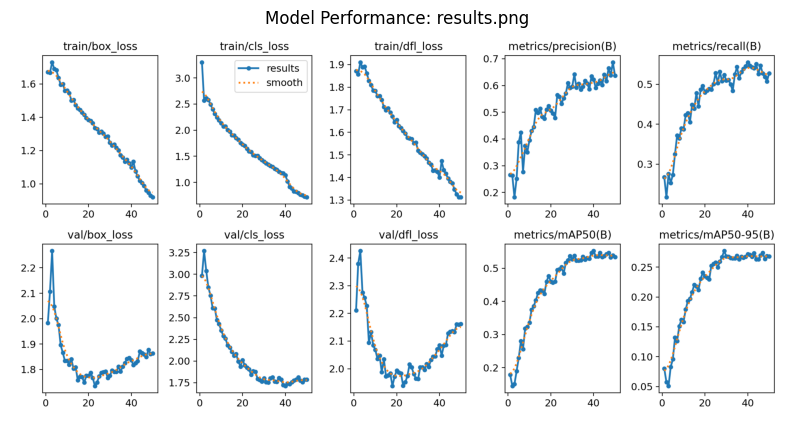

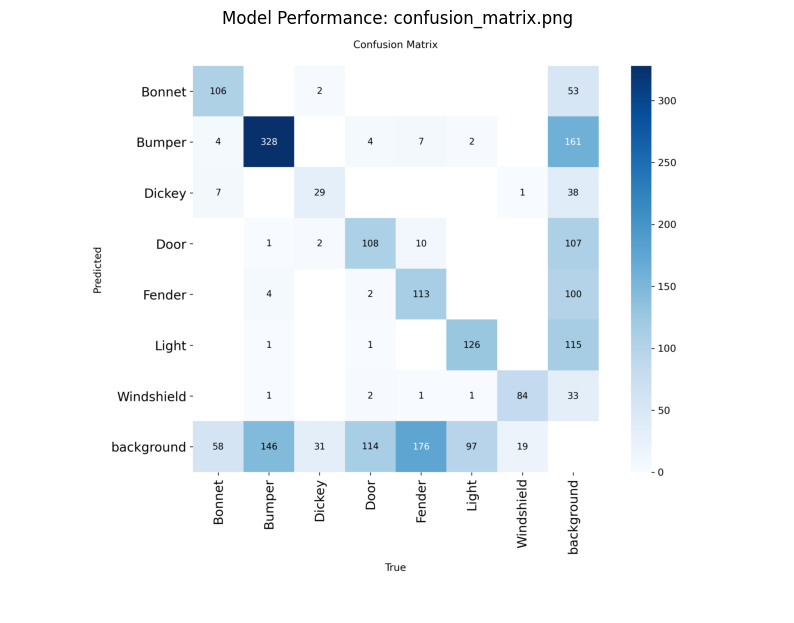

⚠️ Still processing: F1_curve.png is not in this folder yet.
⚠️ Still processing: PR_curve.png is not in this folder yet.


In [8]:
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

print("🔍 Searching for the latest training results...")

# 1. Updated path to exactly match your YOLOv8 output log
search_paths = [
    '/content/car_damage_project/runs/detect/vehicle_inspection/custom_damage_detector*'
]

all_dirs = []
for path in search_paths:
    all_dirs.extend(glob.glob(path))

# 2. Find the newest folder if multiple exist
if all_dirs:
    # Sort folders by creation time to get the most recent one
    results_dir = max(all_dirs, key=os.path.getmtime)
    print(f"✅ Success! Found your latest training data at: {results_dir}\n")

    # 3. Display the images
    performance_images = [
        'results.png', 'confusion_matrix.png',
        'F1_curve.png', 'PR_curve.png'
    ]

    for img_name in performance_images:
        img_path = os.path.join(results_dir, img_name)
        if os.path.exists(img_path):
            plt.figure(figsize=(10, 8))
            img = mpimg.imread(img_path)
            plt.imshow(img)
            plt.title(f'Model Performance: {img_name}')
            plt.axis('off')
            plt.show()
        else:
            print(f"⚠️ Still processing: {img_name} is not in this folder yet.")
else:
    print("❌ Could not find any completed training folders. Are you sure the training cell reached 50/50 epochs?")

## 4. Load Custom Trained Model

In [10]:
import os
import glob
import matplotlib.pyplot as plt
import cv2
from ultralytics import YOLO

# Automatically search for the newest best.pt file
search_path = '/content/car_damage_project/runs/detect/vehicle_inspection/custom_damage_detector*/weights/best.pt'
all_weights = glob.glob(search_path)

if all_weights:
    # Get the most recently modified model file
    custom_weights_path = max(all_weights, key=os.path.getmtime)
    print(f"✅ Success! Your newest model file was found at: {custom_weights_path}")
    print("You can now download this 'best.pt' file from the files panel on the left.")

    # Load your brand new custom model
    my_custom_model = YOLO(custom_weights_path)
    print("Model loaded successfully!")

else:
    print("❌ Weights file not found. Check if the training finished saving the best.pt file.")

✅ Success! Your newest model file was found at: /content/car_damage_project/runs/detect/vehicle_inspection/custom_damage_detector/weights/best.pt
You can now download this 'best.pt' file from the files panel on the left.
Model loaded successfully!


## 5. Download Custom Model

In [11]:
import os
import glob
from google.colab import files

# Automatically search for the newest best.pt file
search_path = '/content/car_damage_project/runs/detect/vehicle_inspection/custom_damage_detector*/weights/best.pt'
all_weights = glob.glob(search_path)

if all_weights:
    # Get the most recently modified model file
    custom_weights_path = max(all_weights, key=os.path.getmtime)
    print(f"✅ Found newest model at: {custom_weights_path}")

    # Trigger the browser download
    print("Downloading 'best.pt' to your local machine...")
    files.download(custom_weights_path)
else:
    print("❌ Error: Model file not found. Please ensure the training completed successfully.")

✅ Found newest model at: /content/car_damage_project/runs/detect/vehicle_inspection/custom_damage_detector/weights/best.pt


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 6. Inspection Pipeline Setup

In [14]:
!pip install ultralytics opencv-python-headless torch torchvision matplotlib

import os
import glob
import cv2
import numpy as np
import torch
import torch.nn as nn
from torchvision import models, transforms
from ultralytics import YOLO
import matplotlib.pyplot as plt
from google.colab import files

# 1. Automatically search for and load YOUR Custom Model
search_path = '/content/car_damage_project/runs/detect/vehicle_inspection/custom_damage_detector*/weights/best.pt'
all_weights = glob.glob(search_path)

if all_weights:
    custom_weights_path = max(all_weights, key=os.path.getmtime)
    damage_model = YOLO(custom_weights_path)
    print(f"✅ Custom YOLOv8 Model Loaded Successfully from: {custom_weights_path}")
else:
    print("❌ Error: Model weights not found. Please check your training output.")

# 2. Setup Vehicle Verification Model (ResNet)
weights = models.ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=weights)
feature_extractor = torch.nn.Sequential(*(list(resnet.children())[:-1]))
feature_extractor.eval()

preprocess = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

✅ Custom YOLOv8 Model Loaded Successfully from: /content/car_damage_project/runs/detect/vehicle_inspection/custom_damage_detector/weights/best.pt


### 6.1 Upload 'Before' Images

In [15]:
print("=== STEP 1: UPLOAD 'BEFORE' IMAGES SEQUENTIALLY ===")
views = ["Front", "Rear", "Left", "Right"]
paths_before = []

for view in views:
    print(f"\n📁 Please upload the {view} View (BEFORE):")
    uploaded = files.upload()

    # Extract the filename of the uploaded file
    file_name = list(uploaded.keys())[0]
    paths_before.append(file_name)
    print(f"✅ Logged {view} Before image: {file_name}")

print("\nAll 4 'Before' images successfully mapped!")

=== STEP 1: UPLOAD 'BEFORE' IMAGES SEQUENTIALLY ===

📁 Please upload the Front View (BEFORE):


Saving WhatsApp Image 2026-06-09 at 14.06.30.jpeg to WhatsApp Image 2026-06-09 at 14.06.30.jpeg
✅ Logged Front Before image: WhatsApp Image 2026-06-09 at 14.06.30.jpeg

📁 Please upload the Rear View (BEFORE):


Saving WhatsApp Image 2026-06-09 at 14.06.29.jpeg to WhatsApp Image 2026-06-09 at 14.06.29.jpeg
✅ Logged Rear Before image: WhatsApp Image 2026-06-09 at 14.06.29.jpeg

📁 Please upload the Left View (BEFORE):


Saving WhatsApp Image 2026-06-09 at 14.06.28 (1).jpeg to WhatsApp Image 2026-06-09 at 14.06.28 (1).jpeg
✅ Logged Left Before image: WhatsApp Image 2026-06-09 at 14.06.28 (1).jpeg

📁 Please upload the Right View (BEFORE):


Saving WhatsApp Image 2026-06-09 at 14.06.28 (3).jpeg to WhatsApp Image 2026-06-09 at 14.06.28 (3).jpeg
✅ Logged Right Before image: WhatsApp Image 2026-06-09 at 14.06.28 (3).jpeg

All 4 'Before' images successfully mapped!


### 6.2 Upload 'After' Images

In [27]:
print("=== STEP 2: UPLOAD 'AFTER' IMAGES SEQUENTIALLY ===")
paths_after = []

for view in views:
    print(f"\n📁 Please upload the {view} View (AFTER):")
    uploaded = files.upload()

    # Extract the filename of the uploaded file
    file_name = list(uploaded.keys())[0]
    paths_after.append(file_name)
    print(f"✅ Logged {view} After image: {file_name}")

print("\nAll 4 'After' images successfully mapped!")

=== STEP 2: UPLOAD 'AFTER' IMAGES SEQUENTIALLY ===

📁 Please upload the Front View (AFTER):


Saving WhatsApp Image 2026-06-09 at 14.06.30.jpeg to WhatsApp Image 2026-06-09 at 14.06.30 (2).jpeg
✅ Logged Front After image: WhatsApp Image 2026-06-09 at 14.06.30 (2).jpeg

📁 Please upload the Rear View (AFTER):


Saving WhatsApp Image 2026-06-09 at 14.06.29.jpeg to WhatsApp Image 2026-06-09 at 14.06.29 (1).jpeg
✅ Logged Rear After image: WhatsApp Image 2026-06-09 at 14.06.29 (1).jpeg

📁 Please upload the Left View (AFTER):


Saving WhatsApp Image 2026-06-09 at 14.06.28 (1).jpeg to WhatsApp Image 2026-06-09 at 14.06.28 (1) (2).jpeg
✅ Logged Left After image: WhatsApp Image 2026-06-09 at 14.06.28 (1) (2).jpeg

📁 Please upload the Right View (AFTER):


Saving WhatsApp Image 2026-06-09 at 14.06.28 (3).jpeg to WhatsApp Image 2026-06-09 at 14.06.28 (3) (2).jpeg
✅ Logged Right After image: WhatsApp Image 2026-06-09 at 14.06.28 (3) (2).jpeg

All 4 'After' images successfully mapped!


### 6.3 Image Alignment Function

In [28]:
def align_images(img_before, img_after):
    """Aligned with fallback safety checks to avoid bounding box shifts."""
    gray_before = cv2.cvtColor(img_before, cv2.COLOR_BGR2GRAY)
    gray_after = cv2.cvtColor(img_after, cv2.COLOR_BGR2GRAY)

    # Increase features to capture subtle panel lines
    orb = cv2.ORB_create(nfeatures=8000)
    kp1, des1 = orb.detectAndCompute(gray_before, None)
    kp2, des2 = orb.detectAndCompute(gray_after, None)

    if des1 is None or des2 is None:
        return img_after

    bf = cv2.BFMatcher(cv2.NORM_HAMMING, crossCheck=True)
    matches = bf.match(des1, des2)
    matches = sorted(matches, key=lambda x: x.distance)

    # Require at least 15 good structural matches
    good_matches = max(int(len(matches) * 0.15), 15)
    if len(matches) < 15:
        print("⚠️ Poor structural alignment detected. Using original coordinates.")
        return img_after

    points_before = np.zeros((good_matches, 2), dtype=np.float32)
    points_after = np.zeros((good_matches, 2), dtype=np.float32)

    for i, match in enumerate(matches[:good_matches]):
        points_before[i, :] = kp1[match.queryIdx].pt
        points_after[i, :] = kp2[match.trainIdx].pt

    h, mask = cv2.findHomography(points_after, points_before, cv2.RANSAC, 5.0)

    # Safety Check: If the warping matrix is too extreme, don't use it
    if h is None or np.abs(np.linalg.det(h)) < 0.6 or np.abs(np.linalg.det(h)) > 1.4:
        print("⚠️ Skewed alignment matrix rejected. Keeping image raw.")
        return img_after

    height, width, channels = img_before.shape
    return cv2.warpPerspective(img_after, h, (width, height))

## 7. Run Master Inspection Pipeline and Visualize Results


--- PHASE 1: ALIGNMENT & IDENTITY VERIFICATION ---
 -> Front Structural Match: 1.00
 -> Rear Structural Match: 1.00
 -> Left Structural Match: 1.00
 -> Right Structural Match: 1.00

Final Identity Score: 1.00

✅ Verification Passed! Scan complete. Showing localized NEW damages...


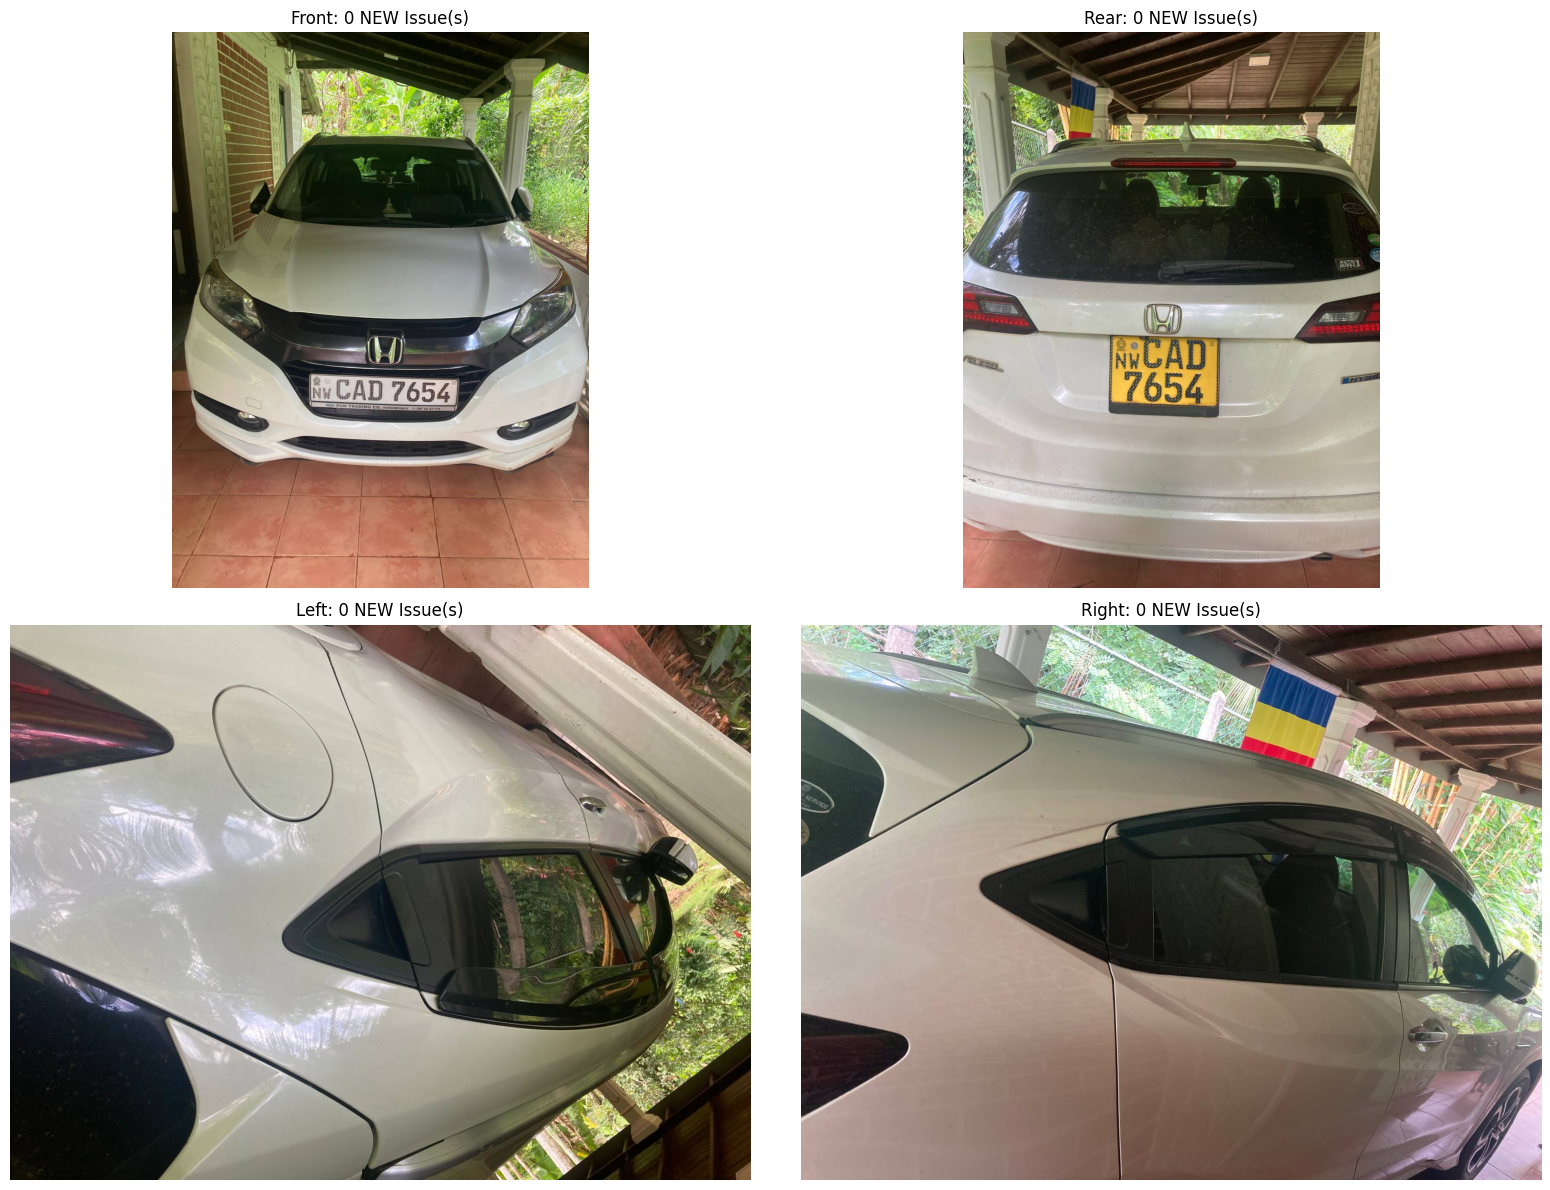

In [29]:
import torch.nn as nn

# ==========================================
# HELPER FUNCTION 1: Image Similarity (ResNet)
# ==========================================
def verify_single_view(img1, img2):
    tensor1 = preprocess(img1).unsqueeze(0)
    tensor2 = preprocess(img2).unsqueeze(0)

    with torch.no_grad():
        feat1 = feature_extractor(tensor1).flatten()
        feat2 = feature_extractor(tensor2).flatten()

    cos = nn.CosineSimilarity(dim=0)
    similarity = cos(feat1, feat2).item()
    return similarity

# ==========================================
# HELPER FUNCTION 2: Bounding Box Overlap (IoU)
# ==========================================
def calculate_iou(box1, box2):
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0

    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

    iou = intersection_area / float(box1_area + box2_area - intersection_area)
    return iou

# ==========================================
# MASTER PIPELINE FUNCTION
# ==========================================
def run_master_inspection_pipeline(
    before_list,
    after_list,
    yolo_confidence=0.1,        # Pulled from your UI screenshot
    iou_threshold=0.1,          # Pulled from your UI screenshot
    verification_threshold=0.5  # Pulled from your UI screenshot
):
    if len(before_list) != 4 or len(after_list) != 4:
        print("❌ Error: Missing files. Please re-run the upload cells.")
        return

    view_labels = ["Front", "Rear", "Left", "Right"]
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    axes = axes.ravel()
    total_similarity = 0

    print("\n--- PHASE 1: ALIGNMENT & IDENTITY VERIFICATION ---")
    for i in range(4):
        # Load and convert images safely
        img_b = cv2.cvtColor(cv2.imread(before_list[i]), cv2.COLOR_BGR2RGB)
        img_a = cv2.cvtColor(cv2.imread(after_list[i]), cv2.COLOR_BGR2RGB)

        # Align After to Before
        aligned_a = align_images(img_b, img_a)

        # Verify using UI Threshold
        sim_score = verify_single_view(img_b, aligned_a)
        total_similarity += sim_score
        print(f" -> {view_labels[i]} Structural Match: {sim_score:.2f}")

        # --- PHASE 2: CUSTOM DAMAGE DETECTION & FILTERING ---
        # Using the UI Confidence (0.1) for both scans
        results_before = damage_model(img_b, conf=yolo_confidence, verbose=False)[0]
        results_after = damage_model(aligned_a, conf=yolo_confidence, verbose=False)[0]

        boxes_before = results_before.boxes.xyxy.cpu().numpy()
        boxes_after = results_after.boxes.xyxy.cpu().numpy()
        classes_after = results_after.boxes.cls.cpu().numpy()
        class_names = damage_model.names

        new_damages_found = 0
        display_img = aligned_a.copy()

        for j, box_after in enumerate(boxes_after):
            is_pre_existing = False

            for box_before in boxes_before:
                # Using the UI IoU Threshold (0.1)
                if calculate_iou(box_after, box_before) > iou_threshold:
                    is_pre_existing = True
                    break

            if not is_pre_existing:
                new_damages_found += 1
                x1, y1, x2, y2 = map(int, box_after)
                label = f"NEW: {class_names[int(classes_after[j])]}"

                cv2.rectangle(display_img, (x1, y1), (x2, y2), (255, 0, 0), 4)
                cv2.putText(display_img, label, (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 0, 0), 2)

        # Render to plot
        axes[i].imshow(display_img)
        axes[i].set_title(f"{view_labels[i]}: {new_damages_found} NEW Issue(s)")
        axes[i].axis('off')

    avg_similarity = total_similarity / 4
    print(f"\nFinal Identity Score: {avg_similarity:.2f}")

    if avg_similarity < verification_threshold:
        print("\n❌ ALERT: SYSTEM REFUSED. The returned vehicle pictures do not match.")
        return

    print("\n✅ Verification Passed! Scan complete. Showing localized NEW damages...")
    plt.tight_layout()
    plt.show()

# Trigger the final system!
run_master_inspection_pipeline(paths_before, paths_after)